## 1. Описание ноутбука

Здесь представлен сбор данных по финансовым новостям из разных источников (гитхаб, kaggle, соцсеть Пульс)

Сначала показано обучение моделей в задаче определения семантики новостей

Затем проводятся эксперименты с механизмом выделения из новости тикеров тех активов, которые она затрагивает

Для удобства в рамках этого учебного проекта взято ~20 акций крупных компаний Московской биржи.

## 2. Импорты и конфигурация

In [1]:
import os
import re
import ast
import json
import time
import datetime
import platform
import warnings

import pytz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)

from catboost import CatBoostClassifier, Pool

import pymorphy2
from tqdm.notebook import tqdm

from tpulse import TinkoffPulse
from t_tech.invest import Client, CandleInterval

warnings.filterwarnings('ignore')

In [2]:
TBANK_TOKEN = "токен из Т-инвестиций"

LABEL_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL  = {0: 'negative', 1: 'neutral', 2: 'positive'}
N_LABELS  = 3

MAX_LEN       = 512
BATCH_SIZE    = 8
EPOCHS        = 3
N_DAYS_HORIZON = 5
RANDOM_STATE  = 42

TICKERS = [
    'SBER', 'LKOH', 'GAZP', 'ROSN', 'NVTK', 'GMKN', 'MGNT', 'TATN',
    'YNDX', 'MTSS', 'PLZL', 'CHMF', 'MAGN', 'ALRS', 'PHOR',
    'SNGS', 'SNGSP', 'TCSG', 'FIVE', 'OZON',
]

TICKER_KEYWORDS = {
    'SBER':  ['сбер', 'сбербанк'],
    'LKOH':  ['лукойл', 'lukoil'],
    'GAZP':  ['газпром', 'gazprom'],
    'ROSN':  ['роснефть', 'rosneft'],
    'NVTK':  ['новатэк', 'novatek'],
    'GMKN':  ['норникель', 'nornickel', 'гмк'],
    'MGNT':  ['магнит', 'magnit'],
    'TATN':  ['татнефть', 'tatneft'],
    'YNDX':  ['яндекс', 'yandex'],
    'MTSS':  ['мтс', ' mts '],
    'PLZL':  ['полюс', 'polyus'],
    'CHMF':  ['северсталь', 'severstal'],
    'MAGN':  ['ммк', 'магнитогорск'],
    'ALRS':  ['алроса', 'alrosa'],
    'PHOR':  ['фосагро', 'phosagro'],
    'SNGS':  ['сургутнефтегаз', 'surgutneftegas'],
    'SNGSP': ['сургутнефтегаз', 'surgutneftegas'],
    'TCSG':  ['тинькофф', 'тбанк', 'tinkoff', 't-bank'],
    'FIVE':  ['x5', 'пятёрочка', 'перекрёсток', 'карусель'],
    'OZON':  ['озон', 'ozon'],
}

OIL_TICKERS = ['LKOH', 'ROSN', 'NVTK', 'TATN', 'SNGS', 'SNGSP', 'GAZP']
METAL_TICKERS = ['GMKN', 'PLZL', 'CHMF', 'MAGN', 'ALRS']

MACRO_KEYWORDS = {
    'oil':       (['нефть', 'brent', 'crude', 'баррель', 'опек', 'opec'], OIL_TICKERS),
    'metals':    (['металл', 'сталь', 'никель', 'палладий', 'алмаз'], METAL_TICKERS),
    'ruble':     (['рубль', 'курс доллара', 'курс евро', 'девальвац', 'цб рф', 'банк росс'], TICKERS),
    'sanctions': (['санкци', 'embargo', 'эмбарго'], TICKERS),
    'rate':      (['ключевая ставка', 'процентная ставка', 'цб повыс', 'цб снизи'], TICKERS),
}

In [3]:
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: MPS') # это была неудачная попытка запуститься на маке, пришлось на а100 :)
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Device: CUDA', torch.cuda.get_device_name(0))
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')

USE_FP16 = DEVICE.type == 'cuda'

Device: CUDA NVIDIA A100-SXM4-80GB


## 3. Утилиты для работы с T-Bank API

In [4]:
def cast_money(v):
    return v.units + v.nano / 1e9

def dict_cast_money(v):
    return v['units'] + v['nano'] / 1e9

def get_figi_map(token, tickers):
    figi_map = {}
    with Client(token) as client:
        for ticker in tqdm(tickers, desc='Fetching FIGI'):
            try:
                r = client.instruments.find_instrument(query=ticker)
                for inst in r.instruments:
                    if inst.ticker == ticker and inst.instrument_type == 'share':
                        figi_map[ticker] = inst.figi
                        break
            except Exception as e:
                print(f'  [WARN] {ticker}: {e}')
    return figi_map

def get_candles_df(figi, token, days_back=400):
    now     = datetime.datetime.now(pytz.utc)
    from_dt = now - datetime.timedelta(days=days_back)
    with Client(token) as client:
        r = client.market_data.get_candles(
            figi=figi,
            from_=from_dt,
            to=now,
            interval=CandleInterval.CANDLE_INTERVAL_DAY,
        )
    rows = []
    for c in r.candles:
        rows.append({
            'date':   c.time.date(),
            'open':   dict_cast_money({'units': c.open.units,  'nano': c.open.nano}),
            'close':  dict_cast_money({'units': c.close.units, 'nano': c.close.nano}),
            'high':   dict_cast_money({'units': c.high.units,  'nano': c.high.nano}),
            'low':    dict_cast_money({'units': c.low.units,   'nano': c.low.nano}),
            'volume': c.volume,
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
    return df

def compute_return_label(df_candles, news_date, n_days=5):
    """Возвращает метку тональности по доходности за n_days торговых дней после новости."""
    news_date = pd.to_datetime(news_date)
    future = df_candles[df_candles['date'] >= news_date].reset_index(drop=True)
    if len(future) <= n_days:
        return None
    price_entry = future.loc[0, 'close']
    price_exit  = future.loc[n_days, 'close']
    if price_entry == 0:
        return None
    ret = (price_exit - price_entry) / price_entry
    if ret > 0.015:
        return 'positive'
    elif ret < -0.015:
        return 'negative'
    return 'neutral'

In [5]:
# Получение figi для всех тикеров
figi_map = get_figi_map(TBANK_TOKEN, TICKERS)
print('Найдено figi:', len(figi_map))
print(figi_map)

Fetching FIGI:   0%|          | 0/20 [00:00<?, ?it/s]

Найдено figi: 19
{'SBER': 'TCS704730N88', 'LKOH': 'TCS509024277', 'GAZP': 'TCS907661625', 'ROSN': 'TCS00A0J2Q06', 'NVTK': 'TCS50A0DKVS5', 'GMKN': 'BBG004731489', 'MGNT': 'BBG004RVFCY3', 'TATN': 'BBG004RVFFC0', 'YNDX': 'TCS109805522', 'MTSS': 'TCS007775219', 'PLZL': 'TCS00A0JNAA8', 'CHMF': 'TCS70475K6C3', 'MAGN': 'BBG004S68507', 'ALRS': 'BBG004S68B31', 'PHOR': 'BBG004S689R0', 'SNGS': 'TCS008926258', 'SNGSP': 'RU0009029524', 'FIVE': 'TCS8387E2054', 'OZON': 'TCS80A10CW95'}


## 4. Загрузка датасетов

### 4.1 FiNeS — единственный датасет с готовыми метками

Файл: `data/data.tsv`  
Колонки: `title`, `score` ([-1, +1]), `published`, `tickers`, `link`, `summary`  
Источник: `git clone https://github.com/WebOfRussia/financial-news-sentiment`

In [6]:
!git clone https://github.com/WebOfRussia/financial-news-sentiment fines_repo 2>/dev/null || echo 'Already cloned'

Already cloned


In [7]:
fines_df = pd.read_csv('financial-news-sentiment/data/data.tsv', sep='\t')
print('FiNeS shape:', fines_df.shape)
print('Колонки:', fines_df.columns.tolist())
fines_df.head(3)

FiNeS shape: (532, 6)
Колонки: ['title', 'score', 'link', 'summary', 'published', 'tickers']


,title,score,link,summary,published,tickers
0,Электромобильный стартап Arrival экс-главы Yot...,-0.583333,https://www.rbc.ru/technology_and_media/12/05/...,"Британский электромобильный стартап Arrival, к...","Thu, 12 May 2022 05:10:01 +0300",['ARVL']
1,Экс-глава НМТП рассказал о «напряженных отноше...,-0.314286,https://www.rbc.ru/society/16/11/2020/5fb2709d...,Экс-председатель совета директоров Новороссийс...,"Fri, 20 May 2022 19:13:18 +0300",['NMTP']
2,Шрёдер отклонил предложение войти в совет дире...,-0.333333,https://www.rbc.ru/business/20/05/2022/628772b...,Его кандидатуру выдвинули в начале февраля. Ка...,"Tue, 24 May 2022 22:12:05 +0300",['GAZP']


In [8]:
def fines_score_to_label(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    return 'neutral'

fines_df['sentiment_label'] = fines_df['score'].apply(fines_score_to_label)
fines_df['label_id']        = fines_df['sentiment_label'].map(LABEL_MAP)

fines_df['tickers_list'] = fines_df['tickers'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

fines_df['text'] = (
    fines_df['title'].fillna('') + ' [SEP] ' + fines_df['summary'].fillna('')
)

print('Распределение меток (FiNeS):')
print(fines_df['sentiment_label'].value_counts())
fines_df[['title', 'score', 'sentiment_label', 'tickers_list']].head(5)

Распределение меток (FiNeS):
sentiment_label
negative    274
positive    223
neutral      35
Name: count, dtype: int64


,title,score,sentiment_label,tickers_list
0,Электромобильный стартап Arrival экс-главы Yot...,-0.583333,negative,[ARVL]
1,Экс-глава НМТП рассказал о «напряженных отноше...,-0.314286,negative,[NMTP]
2,Шрёдер отклонил предложение войти в совет дире...,-0.333333,negative,[GAZP]
3,Шельф берут в разработку // Генподрядчиком «Га...,0.700000,positive,[GAZP]
4,"Чистый убыток ""Юнипро"" в 1 полугодии 2022 года...",-0.611111,negative,[UPRO]


### 4.2 tpulse-py — парсинг постов из Пульса Т-Банка

Структура поста примерно такая: `id`, `text`, `likesCount`, `commentsCount`, `inserted` (ISO 8601),  
`instruments[].ticker`, `instruments[].relativeDailyYield`, `reactions.counters`

In [9]:
from httpx import HTTPStatusError

def parse_pulse_post(post):
    content     = post.get('content', {})
    instruments = content.get('instruments', [])
    tickers_in_post = [
        instr['ticker']
        for instr in instruments
        if instr.get('type') == 'share'
    ]
    return {
        'id':            post.get('id'),
        'text':          content.get('text', ''),
        'likesCount':    post.get('reactions', {}).get('totalCount', 0),
        'commentsCount': post.get('commentsCount', 0),
        'inserted':      post.get('inserted'),
        'tickers_list':  tickers_in_post,
    }

def collect_pulse_posts(tickers, posts_per_ticker=90, delay=0.5):
    pulse    = TinkoffPulse()
    rows     = []
    # 30 постов за один запрос
    n_pages  = max(1, posts_per_ticker // 30)
    for ticker in tqdm(tickers, desc='Pulse posts'):
        cursor = 999999999
        for _ in range(n_pages):
            try:
                response = pulse.get_posts_by_ticker(ticker, cursor)
                items    = response.get('items', [])
                if not items:
                    break
                for post in items:
                    row = parse_pulse_post(post)
                    if row['text'].strip():
                        rows.append(row)
                cursor = response.get('nextCursor')
                if cursor is None:
                    break
                time.sleep(delay)
            except HTTPStatusError as e:
                print(f'  [WARN] {ticker} HTTP {e.response.status_code}')
                break
            except Exception as e:
                print(f'  [WARN] {ticker}: {e}')
                break
    return pd.DataFrame(rows)

pulse_df = collect_pulse_posts(TICKERS, posts_per_ticker=90)
print('Pulse posts shape:', pulse_df.shape)
pulse_df.head(3)

Pulse posts:   0%|          | 0/20 [00:00<?, ?it/s]

Pulse posts shape: (1697, 6)


,id,text,likesCount,commentsCount,inserted,tickers_list
0,b1875f37-eea7-4235-9f2f-bbd401e99505,"{$SBER} приветствую читателей пульса. Скажите,...",2,17,2025-08-28T05:25:41.826Z,[SBER]
1,327c53dd-bdf9-4265-910c-0453cb7f4a31,Прогноз по цене акций Сбербанка. Плавный разво...,4,1,2025-08-28T05:16:58.980Z,[SBER]
2,6f3f4abe-125e-4345-b0b0-8bc7802abdf6,"🌅 Утро | 28.08.2025\n\n💵 Валюта\n{$SiU5} — 80,...",12,0,2025-08-28T04:49:05.108Z,"[ALRS, NVTK, GAZP, LKOH, CBOM, SBER, PIKK]"


### 4.3 kkhubiev — около 80к русских финансовых статей

Ссылка: https://www.kaggle.com/datasets/kkhubiev/russian-financial-news  

In [10]:
KKHUBIEV_PATH = 'data/RussianFinancialNews/news_collection.parquet'

if os.path.exists(KKHUBIEV_PATH):
    kkhubiev_df = pd.read_parquet(KKHUBIEV_PATH)
    print('kkhubiev shape:', kkhubiev_df.shape)
    print('Колонки:', kkhubiev_df.columns.tolist())
    print(kkhubiev_df.head(3))

    text_col  = 'text'  if 'text'  in kkhubiev_df.columns else kkhubiev_df.columns[0]
    title_col = 'title' if 'title' in kkhubiev_df.columns else None

    kkhubiev_df['text'] = (
        (kkhubiev_df[title_col].fillna('') + ' [SEP] ' if title_col else '') +
        kkhubiev_df[text_col].fillna('')
    )
    kkhubiev_df.head(3)
else:
    print(f'Файл не найден: {KKHUBIEV_PATH}')
    kkhubiev_df = pd.DataFrame(columns=['text'])

kkhubiev shape: (91955, 6)
Колонки: ['title', 'body', 'date', 'time', 'tags', 'source']
      title                                               body        date  \
0  no title  "После падения добычи в 2022-2023 годах Газпро...  2024-09-09   
1  no title          " Рейтинг акций комьюнити РДВ. #опрос   "  2024-09-09   
2  no title  "Нефть Brent упала до $71, Urals - до $60 за б...  2024-09-09   

       time            tags source  
0  16:16:54       ['цифры']    rdv  
1  15:38:21       ['опрос']    rdv  
2  14:40:17  ['шокновости']    rdv  


## 5. Предобработка и разметка через котировки

In [11]:
morph = pymorphy2.MorphAnalyzer()

def lemmatize_text(text, morph_analyzer=morph):
    text  = re.sub(r'[^а-яёa-z\s]', ' ', str(text).lower())
    tokens = [
        morph_analyzer.parse(t)[0].normal_form
        for t in text.split()
        if len(t) > 1
    ]
    return ' '.join(tokens)

def get_relevant_tickers(text):
    """Возвращает список тикеров, которых касается новость (прямо или косвенно)."""
    text_lower = str(text).lower()
    relevant   = set()
    for ticker, keywords in TICKER_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                relevant.add(ticker)
                break
    for macro_key, (kws, affected) in MACRO_KEYWORDS.items():
        for kw in kws:
            if kw in text_lower:
                for t in affected:
                    relevant.add(t)
                break
    return list(relevant)

In [12]:
# Кэш свечей (чтобы не делать повторные запросы)
candles_cache = {}

def get_candles_cached(ticker):
    if ticker not in candles_cache:
        figi = figi_map.get(ticker)
        if figi is None:
            return None
        candles_cache[ticker] = get_candles_df(figi, TBANK_TOKEN, days_back=400)
    return candles_cache[ticker]

def label_df_by_candles(df, text_col='text', date_col='date', tickers_col=None):
    """
    Для каждой строки датафрейма определяет метку тональности
    через изменение котировок за N_DAYS_HORIZON торговых дней.
    Если tickers_col=None, тикеры определяются автоматически из текста.
    """
    labeled_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Labeling via candles'):
        text = str(row[text_col])
        if tickers_col and tickers_col in row.index:
            tickers_for_row = row[tickers_col] if isinstance(row[tickers_col], list) else []
        else:
            tickers_for_row = get_relevant_tickers(text)

        if not tickers_for_row:
            continue

        if date_col not in row.index or pd.isna(row[date_col]):
            continue

        news_date = row[date_col]

        for ticker in tickers_for_row:
            if ticker not in figi_map:
                continue
            df_c  = get_candles_cached(ticker)
            if df_c is None or df_c.empty:
                continue
            label = compute_return_label(df_c, news_date, n_days=N_DAYS_HORIZON)
            if label is None:
                continue
            labeled_rows.append({
                'ticker':          ticker,
                'text':            text,
                'date':            news_date,
                'sentiment_label': label,
                'label_id':        LABEL_MAP[label],
                'source':          row.get('source', 'unknown'),
            })
    return pd.DataFrame(labeled_rows)

In [13]:
fines_df['source'] = 'fines'
fines_df['date']   = pd.to_datetime(fines_df['published'], errors='coerce', utc=True).dt.tz_localize(None)

fines_labeled = label_df_by_candles(
    fines_df,
    text_col='text',
    date_col='date',
    tickers_col='tickers_list',
)
print('FiNeS labeled:', fines_labeled.shape)
print(fines_labeled['sentiment_label'].value_counts())

Labeling via candles:   0%|          | 0/532 [00:00<?, ?it/s]

FiNeS labeled: (16, 6)
sentiment_label
positive    14
negative     2
Name: count, dtype: int64


In [14]:
# Разметка постов Пульса через котировки
pulse_df['source'] = 'pulse'
pulse_df['date']   = pd.to_datetime(pulse_df['inserted'], utc=True, errors='coerce')
pulse_df['date']   = pulse_df['date'].dt.tz_localize(None)

pulse_labeled = label_df_by_candles(
    pulse_df,
    text_col='text',
    date_col='date',
    tickers_col='tickers_list',
)
print('Pulse labeled:', pulse_labeled.shape)

Labeling via candles:   0%|          | 0/1697 [00:00<?, ?it/s]

Pulse labeled: (2019, 6)


In [15]:
if not kkhubiev_df.empty and 'date' in kkhubiev_df.columns:
    kkhubiev_df['source'] = 'kkhubiev'
    kkhubiev_df['date']   = pd.to_datetime(kkhubiev_df['date'], errors='coerce')
    kkhubiev_labeled = label_df_by_candles(
        kkhubiev_df.sample(min(5000, len(kkhubiev_df)), random_state=RANDOM_STATE),
        text_col='text',
        date_col='date',
    )
    print('kkhubiev labeled:', kkhubiev_labeled.shape)
else:
    kkhubiev_labeled = pd.DataFrame(columns=fines_labeled.columns)
    print('нет даты, скип')

Labeling via candles:   0%|          | 0/5000 [00:00<?, ?it/s]

kkhubiev labeled: (1243, 6)


In [16]:
# Объединение всех данных
fines_score_df = fines_df[['text', 'sentiment_label', 'label_id', 'tickers_list']].copy()
fines_score_df['source'] = 'fines_score'

all_parts = [fines_score_df, fines_labeled, pulse_labeled, kkhubiev_labeled]
combined_df = pd.concat(
    [p for p in all_parts if not p.empty],
    ignore_index=True,
)[['text', 'sentiment_label', 'label_id', 'source']]

combined_df = combined_df.dropna(subset=['text', 'label_id'])
combined_df['label_id'] = combined_df['label_id'].astype(int)

print('Итоговый датасет:', combined_df.shape)
print(combined_df['sentiment_label'].value_counts())
print(combined_df['source'].value_counts())

Итоговый датасет: (3810, 4)
sentiment_label
positive    1766
neutral     1127
negative     917
Name: count, dtype: int64
source
pulse          2019
kkhubiev       1243
fines_score     532
fines            16
Name: count, dtype: int64


In [17]:
os.makedirs('data', exist_ok=True)
combined_df.to_csv('data/labeled_combined.csv', index=False)
print('Сохранено: data/labeled_combined.csv')

Сохранено: data/labeled_combined.csv


## 6. EDA

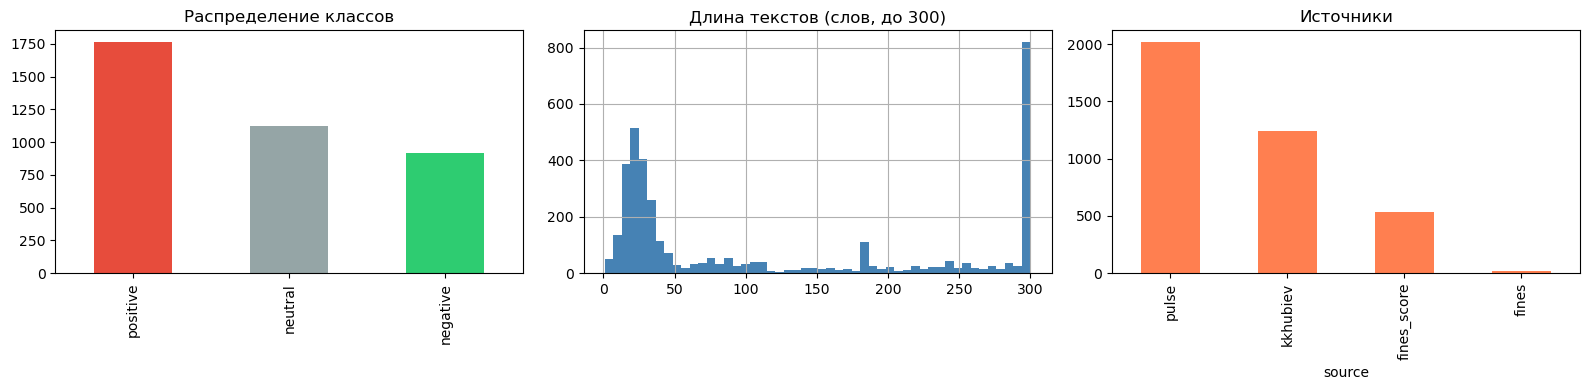


Статистика длин текстов:
count    3810.0
mean      145.6
std       162.3
min         1.0
25%        23.0
50%        45.0
75%       260.0
max       648.0
Name: text_len, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

combined_df['sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#95a5a6', '#2ecc71']
)
axes[0].set_title('Распределение классов')
axes[0].set_xlabel('')

combined_df['text_len'] = combined_df['text'].apply(lambda x: len(str(x).split()))
combined_df['text_len'].clip(upper=300).hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Длина текстов (слов, до 300)')

combined_df['source'].value_counts().plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Источники')

plt.tight_layout()
plt.show()

print('\nСтатистика длин текстов:')
print(combined_df['text_len'].describe().round(1))

## 7. Подготовка train/val/test сплитов

In [19]:
model_df = combined_df[['text', 'label_id', 'sentiment_label']].copy()

train_df, temp_df = train_test_split(
    model_df, test_size=0.2,
    stratify=model_df['label_id'],
    random_state=RANDOM_STATE,
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5,
    stratify=temp_df['label_id'],
    random_state=RANDOM_STATE,
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Лемматизированная версия для baseline
print('Лемматизация для baseline...')
train_df['text_lemma'] = [lemmatize_text(t) for t in tqdm(train_df['text'])]
val_df['text_lemma']   = [lemmatize_text(t) for t in tqdm(val_df['text'])]
test_df['text_lemma']  = [lemmatize_text(t) for t in tqdm(test_df['text'])]

train_df.to_csv('data/train.csv', index=False)
val_df.to_csv('data/val.csv',   index=False)
test_df.to_csv('data/test.csv', index=False)
print('Сплиты сохранены.')

Train: 3048 | Val: 381 | Test: 381
Лемматизация для baseline...


  0%|          | 0/3048 [00:00<?, ?it/s]

  0%|          | 0/381 [00:00<?, ?it/s]

  0%|          | 0/381 [00:00<?, ?it/s]

Сплиты сохранены.


## 8. Метрики

In [20]:
results_summary = {}

def evaluate_model(y_true, y_pred, model_name):
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)

    results_summary[model_name] = {
        'f1_macro':    round(f1_macro, 4),
        'f1_weighted': round(f1_weighted, 4),
        'precision':   round(prec, 4),
        'recall':      round(rec, 4),
    }

    print(f'\n=== {model_name} ===')
    print(f'Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f}')
    print(classification_report(
        y_true, y_pred,
        target_names=list(LABEL_MAP.keys()),
        zero_division=0,
    ))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=list(LABEL_MAP.keys()),
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

    return f1_macro

## 9. Baseline: TF-IDF + LogisticRegression и LinearSVC


=== TF-IDF + LogReg ===
Macro F1: 0.6682 | Weighted F1: 0.7014
              precision    recall  f1-score   support

    negative       0.55      0.51      0.53        92
     neutral       0.59      0.73      0.65       113
    positive       0.87      0.78      0.82       176

    accuracy                           0.70       381
   macro avg       0.67      0.67      0.67       381
weighted avg       0.71      0.70      0.70       381



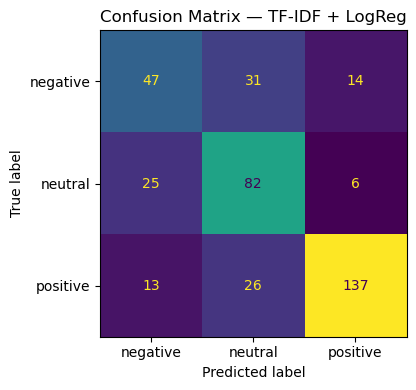

0.6682299733147191

In [21]:
pipe_logreg = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=60000,
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
    )),
])
pipe_logreg.fit(train_df['text_lemma'], train_df['label_id'])
preds_logreg = pipe_logreg.predict(test_df['text_lemma'])
evaluate_model(test_df['label_id'], preds_logreg, 'TF-IDF + LogReg')


=== TF-IDF + LinearSVC ===
Macro F1: 0.6688 | Weighted F1: 0.7012
              precision    recall  f1-score   support

    negative       0.59      0.49      0.54        92
     neutral       0.61      0.70      0.65       113
    positive       0.82      0.82      0.82       176

    accuracy                           0.70       381
   macro avg       0.67      0.67      0.67       381
weighted avg       0.70      0.70      0.70       381



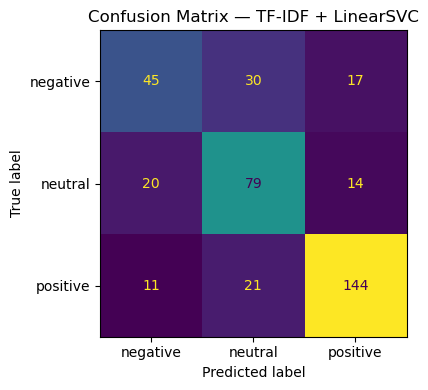

0.6688109558479929

In [22]:
#  TF-IDF + LinearSVC
pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=60000,
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
    )),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        class_weight='balanced',
    )),
])

pipe_svc.fit(train_df['text_lemma'], train_df['label_id'])
preds_svc = pipe_svc.predict(test_df['text_lemma'])
evaluate_model(test_df['label_id'], preds_svc, 'TF-IDF + LinearSVC')

## 10. CatBoost с text_features

0:	learn: 0.5994935	test: 0.6040404	best: 0.6040404 (0)	total: 1.3s	remaining: 43m 24s
200:	learn: 0.7198036	test: 0.6545119	best: 0.6617820 (139)	total: 11.1s	remaining: 1m 38s
400:	learn: 0.7496088	test: 0.6729479	best: 0.6737265 (305)	total: 20.6s	remaining: 1m 22s
bestTest = 0.6737264838
bestIteration = 305
Shrink model to first 306 iterations.

=== CatBoost text_features ===
Macro F1: 0.6198 | Weighted F1: 0.6613
              precision    recall  f1-score   support

    negative       0.60      0.28      0.39        92
     neutral       0.60      0.79      0.68       113
    positive       0.76      0.82      0.79       176

    accuracy                           0.68       381
   macro avg       0.66      0.63      0.62       381
weighted avg       0.68      0.68      0.66       381



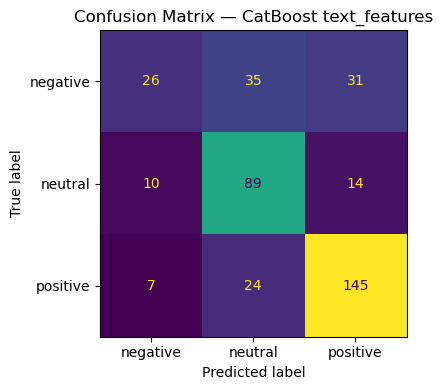

0.6198424163752975

In [23]:
# catBoost принимает текст напрямую через text_features
# передаём сырой текст 

X_train_cb = train_df[['text']].copy()
X_val_cb   = val_df[['text']].copy()
X_test_cb  = test_df[['text']].copy()

train_pool = Pool(
    data=X_train_cb,
    label=train_df['label_id'].values,
    text_features=[0],  
)
val_pool = Pool(
    data=X_val_cb,
    label=val_df['label_id'].values,
    text_features=[0],
)
test_pool = Pool(
    data=X_test_cb,
    label=test_df['label_id'].values,
    text_features=[0],
)

catboost_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    early_stopping_rounds=100,
    random_seed=RANDOM_STATE,
    verbose=200,
    tokenizers=[{
        'tokenizer_id':   'Space',
        'separator_type': 'BySense',
        'lowercasing':    'true',
    }],
    dictionaries=[
        {'dictionary_id': 'Word',   'gram_order': '1', 'max_dictionary_size': '50000'},
        {'dictionary_id': 'Bigram', 'gram_order': '2', 'max_dictionary_size': '30000'},
    ],
    feature_calcers=['BoW:top_tokens_count=10000', 'NaiveBayes', 'BM25'],
     task_type="GPU",
)

catboost_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
preds_cb = catboost_model.predict(test_pool).flatten()
evaluate_model(test_df['label_id'], preds_cb, 'CatBoost text_features')

## 11. Трансформеры

In [24]:
class FinSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro':    f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

def get_training_args(output_dir, batch_size=BATCH_SIZE, epochs=EPOCHS):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=50,
        dataloader_num_workers=0,
        fp16=USE_FP16,
        bf16=False,
        warmup_ratio=0.1,
        weight_decay=0.01,
        report_to='none',
    )

def fine_tune_transformer(model_name, display_name, max_len=MAX_LEN):
    print(f'\n=== Fine-tuning: {display_name} ===')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=N_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL_MAP,
        ignore_mismatched_sizes=True,
    )

    train_dataset = FinSentimentDataset(
        train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, max_len
    )
    val_dataset = FinSentimentDataset(
        val_df['text'].tolist(), val_df['label_id'].tolist(), tokenizer, max_len
    )
    test_dataset = FinSentimentDataset(
        test_df['text'].tolist(), test_df['label_id'].tolist(), tokenizer, max_len
    )

    out_dir = f'./checkpoints/{display_name.replace(" ", "_")}'
    trainer = Trainer(
        model=model,
        args=get_training_args(out_dir),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    preds_output = trainer.predict(test_dataset)
    preds        = np.argmax(preds_output.predictions, axis=-1)
    f1 = evaluate_model(test_df['label_id'].tolist(), preds, display_name)

    model.save_pretrained(f'./saved_models/{display_name.replace(" ", "_")}')
    tokenizer.save_pretrained(f'./saved_models/{display_name.replace(" ", "_")}')

    return model, tokenizer, f1

### 11.1 rubert-tiny2 — быстрая маленькая (29M параметров, контекст 2048)


=== Fine-tuning: rubert-tiny2 ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.690500,0.736498,0.577399,0.623764
2,0.626500,0.715177,0.636649,0.677710
3,0.547700,0.698174,0.640892,0.675359



=== rubert-tiny2 ===
Macro F1: 0.6905 | Weighted F1: 0.7238
              precision    recall  f1-score   support

    negative       0.69      0.45      0.54        92
     neutral       0.63      0.75      0.69       113
    positive       0.82      0.87      0.84       176

    accuracy                           0.73       381
   macro avg       0.71      0.69      0.69       381
weighted avg       0.73      0.73      0.72       381



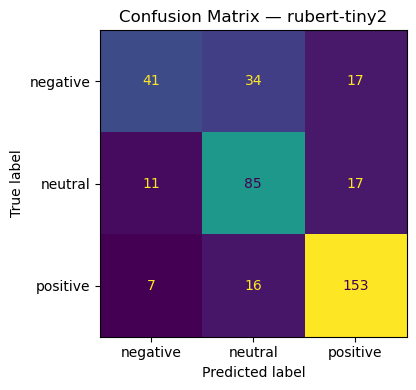

In [25]:
model_tiny2, tok_tiny2, f1_tiny2 = fine_tune_transformer(
    model_name='cointegrated/rubert-tiny2',
    display_name='rubert-tiny2',
    max_len=512,
)

Уже можно видеть значительное улучшение скора даже всего после небольшого числа эпох

### 11.2 ruBERT-base (ai-forever) — предположительно оптимальная (178M параметров)


=== Fine-tuning: ruBERT-base ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.714000,0.744549,0.667427,0.696875
2,0.567300,0.681517,0.685905,0.714854
3,0.479800,0.714888,0.677584,0.708431



=== ruBERT-base ===
Macro F1: 0.6959 | Weighted F1: 0.7253
              precision    recall  f1-score   support

    negative       0.75      0.43      0.55        92
     neutral       0.58      0.91      0.71       113
    positive       0.89      0.77      0.83       176

    accuracy                           0.73       381
   macro avg       0.74      0.70      0.70       381
weighted avg       0.77      0.73      0.73       381



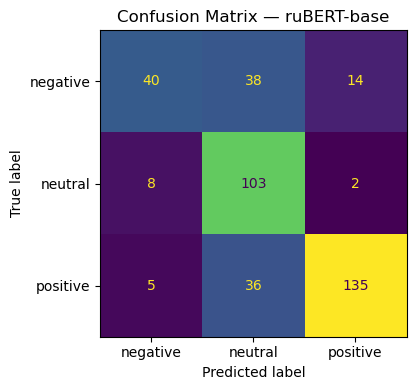

In [26]:
model_base, tok_base, f1_base = fine_tune_transformer(
    model_name='ai-forever/ruBert-base',
    display_name='ruBERT-base',
)

### 11.3 ruBERT-base-cased (от DeepPavlov) — альтернативная base-модель для сравнения


=== Fine-tuning: ruBERT-base-cased-DeepPavlov ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.804800,0.855665,0.481608,0.555664
2,0.775000,0.819888,0.474789,0.546871
3,0.780100,0.820649,0.532766,0.595599



=== ruBERT-base-cased-DeepPavlov ===
Macro F1: 0.5644 | Weighted F1: 0.6202
              precision    recall  f1-score   support

    negative       0.67      0.13      0.22        92
     neutral       0.54      0.96      0.69       113
    positive       0.82      0.76      0.79       176

    accuracy                           0.66       381
   macro avg       0.67      0.61      0.56       381
weighted avg       0.70      0.66      0.62       381



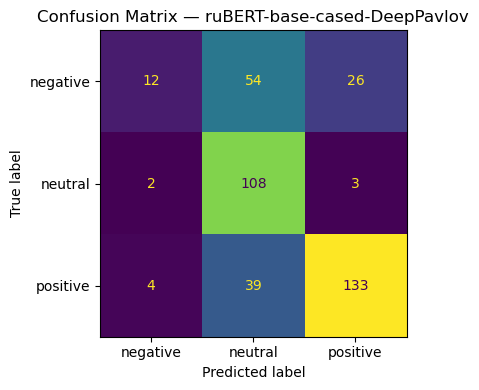

In [27]:
model_dp, tok_dp, f1_dp = fine_tune_transformer(
    model_name='DeepPavlov/rubert-base-cased',
    display_name='ruBERT-base-cased-DeepPavlov',
)

Вывод: модель от DeepPavlov гораздо лучше справляется с neutral и positive, но плохо распознает negative

## 11.4 Попробуем дообучить опенсорную уже обученную под какие-то финансовые данные модель


=== Fine-tuning: rubert-tiny2-finsent-finetuned ===


Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.712900,0.743412,0.606700,0.651232
2,0.611000,0.711427,0.646467,0.679622
3,0.503500,0.720899,0.659910,0.689382



=== rubert-tiny2-finsent-finetuned ===
Macro F1: 0.6796 | Weighted F1: 0.7117
              precision    recall  f1-score   support

    negative       0.63      0.47      0.54        92
     neutral       0.65      0.70      0.68       113
    positive       0.79      0.86      0.83       176

    accuracy                           0.72       381
   macro avg       0.69      0.68      0.68       381
weighted avg       0.71      0.72      0.71       381



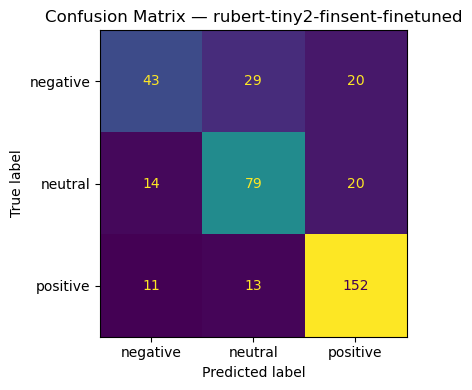

In [28]:
model_mxlcw, tok_mxlcw, f1_mxlcw = fine_tune_transformer(
    model_name='mxlcw/rubert-tiny2-russian-financial-sentiment',
    display_name='rubert-tiny2-finsent-finetuned',
    max_len=512,
)

## 13. Итоговое сравнение для задачи сентимента

In [29]:
comparison_df = pd.DataFrame(results_summary).T.reset_index()
comparison_df.columns = ['Model', 'F1 Macro', 'F1 Weighted', 'Precision', 'Recall']
comparison_df = comparison_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

                         Model  F1 Macro  F1 Weighted  Precision  Recall
                   ruBERT-base    0.6959       0.7253     0.7436  0.7044
                  rubert-tiny2    0.6905       0.7238     0.7142  0.6891
rubert-tiny2-finsent-finetuned    0.6796       0.7117     0.6923  0.6767
            TF-IDF + LinearSVC    0.6688       0.7012     0.6742  0.6688
               TF-IDF + LogReg    0.6682       0.7014     0.6718  0.6716
        CatBoost text_features    0.6198       0.6613     0.6564  0.6314
  ruBERT-base-cased-DeepPavlov    0.5644       0.6202     0.6750  0.6140


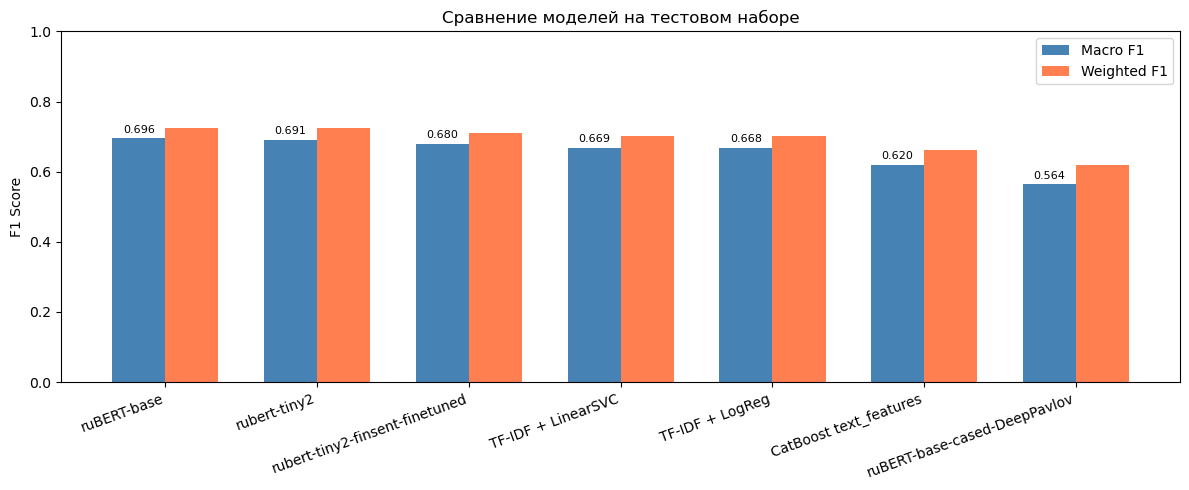

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
x     = range(len(comparison_df))
width = 0.35

bars1 = ax.bar(
    [i - width/2 for i in x],
    comparison_df['F1 Macro'],
    width, label='Macro F1', color='steelblue',
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    comparison_df['F1 Weighted'],
    width, label='Weighted F1', color='coral',
)

ax.set_xticks(list(x))
ax.set_xticklabels(comparison_df['Model'], rotation=20, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Сравнение моделей на тестовом наборе')
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8,
    )

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()

## 14. Анализ релевантности тикеров

In [31]:
ticker_rows = []
for _, row in pd.concat([fines_df, pulse_df], ignore_index=True).iterrows():
    tlist = row.get('tickers_list', [])
    if not isinstance(tlist, list) or not tlist:
        continue
    ticker_rows.append({
        'text':    row['text'],
        'tickers': [t for t in tlist if t in TICKERS],
    })

ticker_df = pd.DataFrame(ticker_rows)
ticker_df = ticker_df[ticker_df['tickers'].apply(len) > 0].reset_index(drop=True)
print('Ticker relevance dataset:', ticker_df.shape)
print('Avg tickers per text:', ticker_df['tickers'].apply(len).mean().round(2))

Ticker relevance dataset: (1711, 2)
Avg tickers per text: 2.45


In [32]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report as cr

mlb = MultiLabelBinarizer(classes=TICKERS)
Y   = mlb.fit_transform(ticker_df['tickers'])

ticker_df['text_lemma'] = [lemmatize_text(t) for t in tqdm(ticker_df['text'], desc='Lemmatizing')]

X_tr_t, X_te_t, Y_tr_t, Y_te_t = train_test_split(
    ticker_df['text_lemma'], Y,
    test_size=0.2, random_state=RANDOM_STATE,
)

# Baseline: TF-IDF + OneVsRest LogReg
pipe_ticker = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=40000,
                               sublinear_tf=True, min_df=1)),
    ('clf',   OneVsRestClassifier(LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs',
    ))),
])

pipe_ticker.fit(X_tr_t, Y_tr_t)
Y_pred_t = pipe_ticker.predict(X_te_t)

prec_t = precision_score(Y_te_t, Y_pred_t, average='macro', zero_division=0)
rec_t  = recall_score(Y_te_t, Y_pred_t, average='macro', zero_division=0)
f1_t   = f1_score(Y_te_t, Y_pred_t, average='macro', zero_division=0)

print(f'Ticker Relevance — TF-IDF + OneVsRest LogReg:')
print(f'  Precision: {prec_t:.4f}')
print(f'  Recall:    {rec_t:.4f}')
print(f'  F1 macro:  {f1_t:.4f}')

Lemmatizing:   0%|          | 0/1711 [00:00<?, ?it/s]

Ticker Relevance — TF-IDF + OneVsRest LogReg:
  Precision: 0.6751
  Recall:    0.6767
  F1 macro:  0.6729


In [50]:
# Transformer-based multi-label: rubert-tiny2 с sigmoid вместо softmax

class TickerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float),
        }

def compute_metrics_multilabel(eval_pred):
    logits, labels = eval_pred
    preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy().astype(int)
    return {
        'f1_macro':    f1_score(labels, preds, average='macro',    zero_division=0),
        'f1_micro':    f1_score(labels, preds, average='micro',    zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
    }

N_TICKERS = len(TICKERS)

X_tr_texts = ticker_df['text'].iloc[X_tr_t.index].tolist()
X_te_texts = ticker_df['text'].iloc[X_te_t.index].tolist()

tok_ticker  = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')
model_ticker = AutoModelForSequenceClassification.from_pretrained(
    'cointegrated/rubert-tiny2',
    num_labels=N_TICKERS,
    problem_type='multi_label_classification',
)

tr_ds_ticker = TickerDataset(X_tr_texts, Y_tr_t.tolist(), tok_ticker, max_len=256)
te_ds_ticker = TickerDataset(X_te_texts, Y_te_t.tolist(), tok_ticker, max_len=256)

import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce  = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        prob = torch.sigmoid(logits)
        p_t  = prob * targets + (1 - prob) * (1 - targets)
        loss = bce * ((1 - p_t) ** self.gamma)
        return loss.mean()


class TickerTrainer(Trainer):
    def __init__(self, pos_weight, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal = FocalLoss(gamma=2.0, pos_weight=pos_weight.to(self.args.device))

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = self.focal(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


#  clip чтобы не было взрыва
Y_tr_tensor   = torch.tensor(Y_tr_t, dtype=torch.float)
pos_counts    = Y_tr_tensor.sum(0).clamp(min=1)
neg_counts    = (len(Y_tr_tensor) - pos_counts).clamp(min=1)
pos_weight    = (neg_counts / pos_counts).clamp(max=20.0)

model_ticker = AutoModelForSequenceClassification.from_pretrained(
    'cointegrated/rubert-tiny2',
    num_labels=N_TICKERS,
    problem_type='multi_label_classification',
)

trainer_ticker = TickerTrainer(
    pos_weight=pos_weight,
    model=model_ticker,
    args=TrainingArguments(
        output_dir='./checkpoints/ticker_relevance',
        num_train_epochs=25,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_micro',
        greater_is_better=True,
        logging_steps=20,
        dataloader_num_workers=0,
        fp16=USE_FP16,
        bf16=False,
        warmup_ratio=0.1,
        weight_decay=0.01,
        report_to='none',
    ),
    train_dataset=tr_ds_ticker,
    eval_dataset=te_ds_ticker,
    compute_metrics=compute_metrics_multilabel,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_ticker.train()

preds_ticker_output = trainer_ticker.predict(te_ds_ticker)
raw_probs = torch.sigmoid(torch.tensor(preds_ticker_output.predictions)).numpy()

best_thresh, best_f1 = 0.5, 0.0
for thresh in np.arange(0.05, 0.95, 0.05):
    preds_bin        = (raw_probs >= thresh).astype(int)
    f1_candidate     = f1_score(Y_te_t, preds_bin, average='micro', zero_division=0)
    print(f'  thresh={thresh:.2f}  micro-F1={f1_candidate:.4f}')
    if f1_candidate > best_f1:
        best_f1     = f1_candidate
        best_thresh = thresh

print(f'\nОптимальный порог: {best_thresh:.2f}  micro-F1={best_f1:.4f}')
preds_ticker_bin = (raw_probs >= best_thresh).astype(int)

prec_tr = precision_score(Y_te_t, preds_ticker_bin, average='macro', zero_division=0)
rec_tr  = recall_score(Y_te_t,    preds_ticker_bin, average='macro', zero_division=0)
f1_tr   = f1_score(Y_te_t,        preds_ticker_bin, average='macro', zero_division=0)

print(f'\nTicker Relevance — rubert-tiny2 multi-label:')
print(f'  Precision: {prec_tr:.4f}')
print(f'  Recall:    {rec_tr:.4f}')
print(f'  F1 macro:  {f1_tr:.4f}')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,F1 Weighted
1,0.255800,0.247886,0.216869,0.303571,0.329747
2,0.232300,0.208151,0.327954,0.412480,0.460375
3,0.186100,0.163072,0.406906,0.532202,0.552421
4,0.138900,0.134468,0.469277,0.601523,0.632025
5,0.111600,0.116345,0.529926,0.677871,0.688626
6,0.091900,0.107621,0.560651,0.720356,0.728823
7,0.078300,0.102452,0.577856,0.739023,0.747007
8,0.069300,0.094691,0.603729,0.779643,0.785781
9,0.062500,0.090457,0.612900,0.785789,0.794238
10,0.055300,0.087388,0.618084,0.789942,0.793868


  thresh=0.05  micro-F1=0.2155
  thresh=0.10  micro-F1=0.2399
  thresh=0.15  micro-F1=0.3053
  thresh=0.20  micro-F1=0.3966
  thresh=0.25  micro-F1=0.5089
  thresh=0.30  micro-F1=0.6005
  thresh=0.35  micro-F1=0.7001
  thresh=0.40  micro-F1=0.7759
  thresh=0.45  micro-F1=0.8393
  thresh=0.50  micro-F1=0.8795
  thresh=0.55  micro-F1=0.8996
  thresh=0.60  micro-F1=0.9022
  thresh=0.65  micro-F1=0.8919
  thresh=0.70  micro-F1=0.8406
  thresh=0.75  micro-F1=0.7461
  thresh=0.80  micro-F1=0.5621
  thresh=0.85  micro-F1=0.2227
  thresh=0.90  micro-F1=0.0426

Оптимальный порог: 0.60  micro-F1=0.9022

Ticker Relevance — rubert-tiny2 multi-label:
  Precision: 0.7474
  Recall:    0.6758
  F1 macro:  0.7087


In [53]:
best_thresh = 0.38

In [58]:
def get_relevant_tickers_combined(text, threshold=best_thresh):
    kw_tickers = set(get_relevant_tickers(text))

    enc = tok_ticker(
        text, truncation=True, padding=True,
        max_length=256, return_tensors='pt',
    ).to(DEVICE)
    model_ticker.eval()
    with torch.no_grad():
        probs = torch.sigmoid(
            model_ticker.to(DEVICE)(**enc).logits
        ).cpu().numpy()[0]
    ml_tickers = set(TICKERS[i] for i, p in enumerate(probs) if p >= threshold)

    macro_only = set()
    for macro_key, (kws, affected) in MACRO_KEYWORDS.items():
        text_lower = text.lower()
        for kw in kws:
            if kw in text_lower:
                macro_only.update(affected)
                break

    combined = ml_tickers | kw_tickers
    return sorted(combined)


test_examples = [
    'Газпром объявил о рекордных дивидендах за 2023 год, акционеры получат 50 рублей на акцию.',
    'Центральный банк России повысил ключевую ставку до 21%, что усилило давление на фондовый рынок.',
    'Цены на нефть Brent упали ниже 70 долларов на фоне решения ОПЕК+ увеличить добычу.',
    'Сбербанк сообщил о рекордной прибыли по итогам квартала, превысившей ожидания аналитиков.',
    'Яндекс завершил редомициляцию и начал торги на Московской бирже под тикером YDEX.',
]

for text in test_examples:
    print(f'Текст: {text[:75]}...')
    print(f'  Result: {get_relevant_tickers_combined(text, threshold=best_thresh)}')
    print()

Текст: Газпром объявил о рекордных дивидендах за 2023 год, акционеры получат 50 ру...
  Result: ['GAZP']

Текст: Центральный банк России повысил ключевую ставку до 21%, что усилило давлени...
  Result: ['ALRS', 'CHMF', 'FIVE', 'GAZP', 'GMKN', 'LKOH', 'MAGN', 'MGNT', 'MTSS', 'NVTK', 'OZON', 'PHOR', 'PLZL', 'ROSN', 'SBER', 'SNGS', 'SNGSP', 'TATN', 'TCSG', 'YNDX']

Текст: Цены на нефть Brent упали ниже 70 долларов на фоне решения ОПЕК+ увеличить ...
  Result: ['GAZP', 'LKOH', 'NVTK', 'ROSN', 'SNGS', 'SNGSP', 'TATN']

Текст: Сбербанк сообщил о рекордной прибыли по итогам квартала, превысившей ожидан...
  Result: ['SBER']

Текст: Яндекс завершил редомициляцию и начал торги на Московской бирже под тикером...
  Result: ['YNDX']



## 15. Корреляционный анализ: новостной сентимент vs котировки

In [59]:
# Для каждого тикера считаем среднее предсказание лучшей модели
# и корреляцию с фактическим изменением котировок

best_model_name = comparison_df.iloc[0]['Model']
print(f'Лучшая модель: {best_model_name}')

best_model_path = f'./saved_models/{best_model_name.replace(" ", "_")}'
best_tok   = AutoTokenizer.from_pretrained(best_model_path)
best_model = AutoModelForSequenceClassification.from_pretrained(best_model_path)
best_model = best_model.to(DEVICE)
best_model.eval()

Лучшая модель: ruBERT-base


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(120138, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [60]:
def get_sentiment_score(text, model, tokenizer):
    enc = tokenizer(
        text, truncation=True, padding=True,
        max_length=MAX_LEN, return_tensors='pt',
    ).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(best_model(**enc).logits, dim=-1).cpu().numpy()[0]
    # probs: [neg, neu, pos]
    return float(probs[2] - probs[0])

correlation_rows = []

for ticker in tqdm(TICKERS, desc='Correlation analysis'):
    df_c = get_candles_cached(ticker)
    if df_c is None or df_c.empty:
        continue

    ticker_news = combined_df[combined_df['text'].apply(
        lambda t: ticker in get_relevant_tickers(t)
    )].copy()

    if len(ticker_news) < 5:
        continue

    ticker_news['sent_score'] = [
        get_sentiment_score(t, best_model, best_tok)
        for t in ticker_news['text']
    ]

    score_map = {0: -1, 1: 0, 2: 1}
    ticker_news['actual_move'] = ticker_news['label_id'].map(score_map)

    corr = ticker_news['sent_score'].corr(ticker_news['actual_move'])
    correlation_rows.append({'ticker': ticker, 'correlation': corr, 'n': len(ticker_news)})

corr_df = pd.DataFrame(correlation_rows).sort_values('correlation', ascending=False)
print(corr_df.to_string(index=False))

Correlation analysis:   0%|          | 0/20 [00:00<?, ?it/s]

ticker  correlation    n
  MTSS     0.650058 1861
  ALRS     0.647402 2323
  NVTK     0.645831 2460
  MAGN     0.645792 2336
  ROSN     0.640208 2362
  TATN     0.640208 2362
  SNGS     0.640073 2372
 SNGSP     0.640073 2372
  MGNT     0.639047 1834
  PLZL     0.638803 2382
  GMKN     0.638738 2305
  LKOH     0.636803 2420
  OZON     0.615437 1766
  PHOR     0.609545 1871


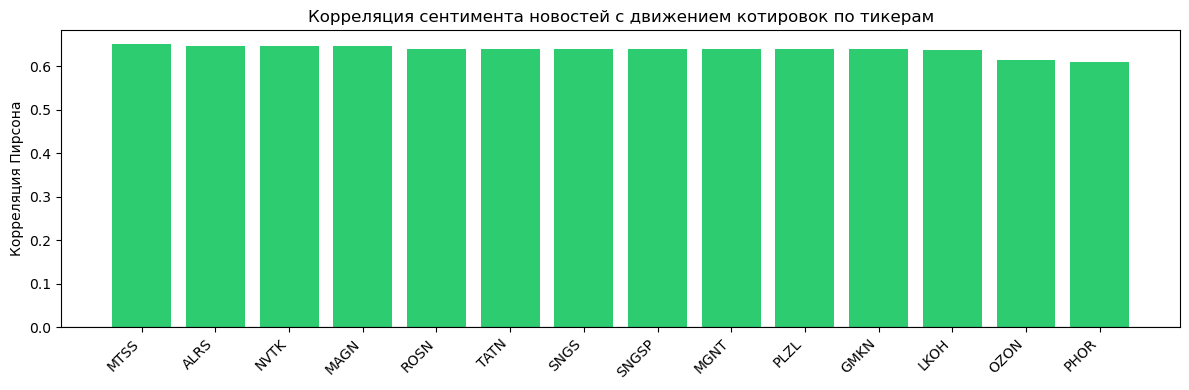

In [61]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#2ecc71' if c >= 0 else '#e74c3c' for c in corr_df['correlation']]
ax.bar(corr_df['ticker'], corr_df['correlation'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Корреляция Пирсона')
ax.set_title('Корреляция сентимента новостей с движением котировок по тикерам')
ax.set_xticklabels(corr_df['ticker'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_by_ticker.png', dpi=150)
plt.show()

## 16. Примеры предсказаний

In [63]:
test_examples = [
    'Газпром объявил о рекордных дивидендах за 2023 год, акционеры получат 50 рублей на акцию.',
    'Центральный банк России повысил ключевую ставку до 21%, что усилило давление на фондовый рынок.',
    'Сбербанк сообщил о рекордной прибыли по итогам квартала, превысившей ожидания аналитиков.',
    'Яндекс завершил редомициляцию и начал торги на Московской бирже под тикером YDEX.',
]
for text in test_examples:
    tickers_found = get_relevant_tickers(text)
    enc  = best_tok(text, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(best_model(**enc).logits, dim=-1).cpu().numpy()[0]
    label = ID2LABEL[int(np.argmax(probs))]
    print(f'\nТекст: {text[:80]}...')
    print(f'  Тикеры:    {tickers_found}')
    print(f'  Сентимент: {label}')
    print(f'  Probs:     neg={probs[0]:.3f} neu={probs[1]:.3f} pos={probs[2]:.3f}')


Текст: Газпром объявил о рекордных дивидендах за 2023 год, акционеры получат 50 рублей ...
  Тикеры:    ['GAZP']
  Сентимент: positive
  Probs:     neg=0.039 neu=0.067 pos=0.895

Текст: Центральный банк России повысил ключевую ставку до 21%, что усилило давление на ...
  Тикеры:    ['PHOR', 'ROSN', 'MTSS', 'MAGN', 'TATN', 'GAZP', 'PLZL', 'NVTK', 'SBER', 'YNDX', 'LKOH', 'FIVE', 'MGNT', 'OZON', 'TCSG', 'CHMF', 'ALRS', 'SNGSP', 'GMKN', 'SNGS']
  Сентимент: negative
  Probs:     neg=0.857 neu=0.046 pos=0.097

Текст: Сбербанк сообщил о рекордной прибыли по итогам квартала, превысившей ожидания ан...
  Тикеры:    ['SBER']
  Сентимент: positive
  Probs:     neg=0.123 neu=0.096 pos=0.781

Текст: Яндекс завершил редомициляцию и начал торги на Московской бирже под тикером YDEX...
  Тикеры:    ['YNDX']
  Сентимент: positive
  Probs:     neg=0.056 neu=0.165 pos=0.779


### Вывод
Видно, что модели реагируют ожидаемо. Дивиденды, редомициляция и рост прибыли - это всегда хорошо. А вот рост ключевой ставки приводит к замедлению роста экономики

## 17. Сохранение итогов

In [64]:
comparison_df.to_csv('results/models_comparison.csv', index=False)
corr_df.to_csv('results/ticker_correlations.csv',     index=False)

print('Сводная таблица результатов:')
print(comparison_df.to_string(index=False))

best_row = comparison_df.iloc[0]
print(f'\nЛучшая модель: {best_row["Model"]}  |  Macro F1 = {best_row["F1 Macro"]}')

Сводная таблица результатов:
                         Model  F1 Macro  F1 Weighted  Precision  Recall
                   ruBERT-base    0.6959       0.7253     0.7436  0.7044
                  rubert-tiny2    0.6905       0.7238     0.7142  0.6891
rubert-tiny2-finsent-finetuned    0.6796       0.7117     0.6923  0.6767
            TF-IDF + LinearSVC    0.6688       0.7012     0.6742  0.6688
               TF-IDF + LogReg    0.6682       0.7014     0.6718  0.6716
        CatBoost text_features    0.6198       0.6613     0.6564  0.6314
  ruBERT-base-cased-DeepPavlov    0.5644       0.6202     0.6750  0.6140

Лучшая модель: ruBERT-base  |  Macro F1 = 0.6959


In [65]:
import os

os.makedirs('models', exist_ok=True)

best_model.save_pretrained('models/sentiment_best')
best_tok.save_pretrained('models/sentiment_best')

model_tiny2.save_pretrained('models/rubert-tiny2')
tok_tiny2.save_pretrained('models/rubert-tiny2')

model_base.save_pretrained('models/rubert-base')
tok_base.save_pretrained('models/rubert-base')

model_dp.save_pretrained('models/rubert-base-cased-dp')
tok_dp.save_pretrained('models/rubert-base-cased-dp')

model_ticker.save_pretrained('models/ticker_relevance')
tok_ticker.save_pretrained('models/ticker_relevance')

import pickle
import joblib

joblib.dump(pipe_logreg,  'models/tfidf_logreg.pkl')
joblib.dump(pipe_svc,     'models/tfidf_svc.pkl')
joblib.dump(pipe_ticker,  'models/ticker_tfidf_ovr.pkl')
joblib.dump(mlb,          'models/ticker_mlb.pkl')

catboost_model.save_model('models/catboost_sentiment.cbm')

meta = {
    'best_thresh':   float(best_thresh),
    'label_map':     LABEL_MAP,
    'id2label':      ID2LABEL,
    'tickers':       TICKERS,
}
with open('models/meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print('Все модели сохранены в ./models/')
os.listdir('models')

Все модели сохранены в ./models/


['tfidf_svc.pkl',
 'sentiment_best',
 'meta.json',
 'tfidf_logreg.pkl',
 'rubert-base',
 'ticker_mlb.pkl',
 'rubert-tiny2',
 'ticker_tfidf_ovr.pkl',
 'ticker_relevance',
 'rubert-base-cased-dp',
 'catboost_sentiment.cbm']